<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/G654E_GN_Colab_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# G.654.E GN 모델 · 단일 main 코드 Colab 보고서

**Launch power → SNR · 고정 물성 유지 · 첨부 파란 곡선 비교**  
작성 기준: 2026-09-08 | 한 개의 코드 셀 | 외부 파일 업로드 없이 실행

이 보고서는 앞서 사용한 G.654.E 계산 코드와 사용자 지정 GitHub 노트북을 정리한 실행본입니다. **감쇠 0.166 dB/km, 유효면적 125 µm², 분산 21 ps/(nm·km), n₂=2.2×10⁻²⁰ m²/W를 변경하지 않습니다.** 기준 파장은 1550 nm입니다.

`USER_INPUTS`에서 계산 종류·span 수·launch power만 선택하고 코드 셀을 실행하면 결과표와 그래프가 갱신됩니다. 계산의 유일한 실행 진입점은 `main(USER_INPUTS)`이며, `.py` 파일도 같은 코드를 담고 있습니다.

**해석 전 확인할 두 가지**

- 원 자료의 **90채널 × 95 GBd × Nyquist spacing = 8.55 THz**는 함께 제시된 **증폭 대역폭 4.8 THz**에 들어가지 않습니다. 모든 원 입력값을 보존한 채, 기본 계산은 90채널 전체에 평탄한 이득이 있다고 가정한 **조건부 결과**로 표시합니다. 실제 4.8 THz 증폭기 시스템을 구현한 결과로 해석하면 안 됩니다.
- 첨부 파란 그래프에는 span 수가 없습니다. 비교 기본값 **30 spans × 80 km = 2,400 km는 가정**입니다. 이전 답변의 `η ×0.5`를 확정된 편파 보정으로 볼 근거는 확인되지 않았습니다. 본 보고서는 기본 GN과 그림에 맞춘 경험적 보정을 구분합니다.

## 1. 필요한 내용 및 수정사항

| 항목 | 기존 코드·이전 답변 | 이번 보고서의 처리 |
|---|---|---|
| 실행 구조 | HCF 모델·그래프 코드·비교 코드가 분리 | 하나의 코드 셀과 `main(USER_INPUTS)`로 통합 |
| 광섬유 물성 | 원 GitHub는 DNANF 기하 모델과 HCF 조건 사용 | G.654.E에는 사용자 물성 네 값을 직접 사용; HCF 기하 보정은 실행하지 않음 |
| 비선형계수 γ | 원 HCF 코드의 지정값 | 고정된 n₂·Aeff·λ로 γ를 계산; γ 자체를 피팅하지 않음 |
| 손실계수 단위 | 원 식은 전계 감쇠계수 사용 | 전력 감쇠계수 `a`와 전계 감쇠계수 `a/2`를 명시적으로 구분 |
| 유효길이 | `L∞=1/a`를 사용하는 장거리 근사 | `Leff=(1-exp(-aL))/a`를 분자에 사용; 원 식도 `legacy`로 보존 |
| NLI span 누적 | 원 함수의 η에 span 수가 포함 | η는 항상 **span당 값**, `NLI=Nspan×η×P³`에서 span 수를 한 번만 곱함 |
| 전력·편파 | 이전 진단에서 추가 ×0.5 적용 | 모든 P·잡음을 **DP 총전력**으로 통일. 기본 GN에는 추가 ×0.5 없음 |
| 파란 곡선에 대한 보정 | 4.8 THz와 ×0.5를 함께 적용 | `calibrated`에서는 90채널과 모든 고정값을 유지하고 **η에 곱하는 k 한 개만** 동일 그림에 피팅 |
| 이전 진단 결과 | η≈28.26, 최대 SNR≈15.16 dB | `historical_diagnostic`으로 재현·공개. 현재 고정 조건과 일치하는 기본 모델은 아님 |
| 오차 표현 | dB 차이 중심 | MAE·RMSE·최대오차는 dB, 백분율 오차는 **선형 SNR**에서 계산 |
| 검증 범위 | 파란 그림과 근접함 | 수식·코드 실행의 검증과 **동일 이미지에 대한 보정 일치도**를 분리 |

유한 `Leff`를 사용해도 전체 GN 적분을 정확히 계산한 것은 아닙니다. 이 코드는 원 노트북의 폐형 근사를 유지한 대표 채널 모델이며, HCF 모델 전체의 정확도를 검증하거나 수정하는 작업은 포함하지 않습니다.

## 2. 코드 실행을 위해 입력한 값

### 2.1 변경 가능한 실행 입력: `USER_INPUTS`

| 키 | 기본값 | 역할 |
|---|---|---|
| `task` | `"all"` | `all`: 전체, `snr`: SNR 곡선, `compare`: 파란 곡선 비교, `point`: 단일 운용점 |
| `model` | `"gn_finite"` | `gn_finite`: 유한 Leff GN, `legacy`: 이전 무한 유효길이 근사, `calibrated`: 경험적 k 적용 |
| `spans` | `list(range(1, 51))` | 1~50 span의 결과를 모두 계산; `[10, 20, 30]`처럼 선택 가능 |
| `launch_min_dbm` / `launch_max_dbm` | `-10.0` / `10.0` | 그래프 전력 탐색 범위, 단위 dBm/channel |
| `launch_step_db` | `0.05` | 그래프 계산 간격; 최적전력은 별도의 해석식으로도 계산 |
| `point_launch_dbm` / `point_spans` | `4.0` / `30` | +4 dBm, 30 spans에서 SNR 및 잡음 성분 확인 |
| `reference_spans_assumed` | `30` | 원 그래프의 span 수가 알려지지 않아 사용하는 비교 가정; 실측값이 아님 |
| `bandwidth_policy` | `"provisional"` | 원 수치를 유지하고 조건부 계산. `"strict"`는 대역폭 불일치를 오류로 알리고 중지 |
| `include_historical_diagnostic` | `False` | `True`이면 이전 4.8 THz·×0.5 진단선을 비교 그림에 추가 |
| `save_outputs` / `show_outputs` | `True` / `True` | CSV·PNG·JSON·ZIP 저장과 화면 출력 |
| `output_dir` | `"G654E_results"` | Colab 실행 폴더 내 결과 저장 위치 |

`task`는 표시할 보고서 항목을 선택합니다. 반환 객체 `RESULTS`와 CSV에는 모든 수치표가 포함됩니다. 지원하지 않는 입력 키로 α·D·Aeff·n₂ 등을 전달하면 오류가 발생합니다.

### 2.2 비교용 데이터

첨부된 파란 곡선을 `-10~+10 dBm`, 0.1 dB 간격으로 읽은 **201개 보간점**을 코드 안에 포함했습니다. 광섬유 물성과는 별도의 비교 데이터이며, `gn_finite`와 `legacy`의 η 계산에는 사용하지 않습니다. `calibrated`의 k를 구할 때만 사용합니다.

픽셀 보정: x=88→−10 dBm, x=653→+10 dBm; y=80→16 dB, y=331→2 dB. 각 x열에서 파란 픽셀의 y 중앙값을 취하고 선형 보간했습니다. y축 한 픽셀은 약 0.056 dB이며, 판독 불확실성은 대략 ±0.1 dB 수준의 추정입니다. 이는 통계적 신뢰구간이 아니며 201점은 독립적인 실측 201회가 아닙니다.

## 3. 출력값

| 출력 | 내용·단위 | 결과 위치 |
|---|---|---|
| SNR 곡선 | 선택한 span별 launch power 대 SNR[dB] | `snr_curves.csv`, SNR 그래프 |
| 최적점 | 해석식 최적전력[dBm], 최대 SNR[dB], 격자 내 최적점 | `optimum_summary.csv` |
| 단일 운용점 | Psignal, PASE, PNLI, PTRX[W], 선형 SNR·SNR[dB] | `operating_point.csv` |
| 계산 파라미터 | γ[W⁻¹km⁻¹], β₂[ps²/km], a[km⁻¹], Leff[km], ASE[W/span] | `derived_parameters.csv` |
| 기준곡선 비교 | 파란 곡선, 기존 GN, 유한 Leff GN, 경험적 보정 GN | `reference_comparison.csv`, 비교 그래프 |
| 오차 | MAE[dB], RMSE[dB], 최대 절대오차[dB], 선형 SNR MAPE[%] | `reference_error_metrics.csv` |
| η와 보정 이력 | 기본·보정·과거 진단 조건별 η[W⁻²/span], 경험적 k | `eta_stages.csv`, JSON |
| 재현 정보 | 사용한 고정값·입력값·가정·코드 원본 해시 | `parameters_and_provenance.json` |

**현재 계산 범위는 SNR입니다.** 실제 64QAM net capacity, BER/GMI, FEC threshold, 해저 리피터 필요 수는 계산하지 않습니다. 64QAM과 Shannon gap 3 dB는 원 조건을 보존하기 위해 기록하며 물리적 SNR 식에 넣지 않습니다. 향후 capacity를 추가할 때는 이러한 성능 매핑과 overhead를 별도로 정의해야 합니다.

`analytic_*`는 탐색 범위 밖에서도 구해지는 이론적 최적점이고, `grid_best_*`는 입력한 탐색 범위에서의 최선값입니다. 범위가 최적점을 포함하는지는 `optimum_inside_scan`으로 표시합니다. 출력의 span 수는 **span 끝의 손실 보상 증폭기를 포함한 모델 개수**이며 해저 습식 리피터 개수로 바로 환산하지 않습니다.

## 4. 고정 값

### 4.1 G.654.E: 변경하지 않은 물성

| 파라미터 | 고정값 | 근거·용도 |
|---|---:|---|
| 감쇠 α | **0.166 dB/km** | 사용자 추가 물성표; span 손실·ASE·η 계산 |
| 유효면적 Aeff | **125 µm²** | 사용자 추가 물성표; γ 계산 |
| 분산 D | **21 ps/(nm·km)** | 사용자 추가 물성표; β₂ 계산 |
| 비선형 굴절률 n₂ | **2.2×10⁻²⁰ m²/W** | 사용자 추가 물성표; γ 계산 |
| 기준 파장 λ | **1550 nm** | 첨부 G.654.E 특성표와 이전 계산 기준 |

위 네 물성은 **이 사례의 사용자 지정값**이며 모든 G.654.E 제품에 공통인 규격값으로 일반화하지 않습니다. MFD, 굽힘손실, 외경, proof stress 등의 항목으로 Aeff나 감쇠를 덮어쓰지 않습니다. 특히 명시된 Aeff가 있으므로 MFD에서 Aeff를 다시 추정하지 않습니다.

### 4.2 보존한 공통 시스템 조건

| 항목 | 고정값 | 적용 |
|---|---:|---|
| WDM 채널 수 | 90 | GN 식에 사용 |
| Symbol rate | 95 GBd | 채널 잡음 적분 대역·GN 식 |
| Channel spacing | 95 GHz | Nyquist 조건 |
| Span 길이 | 80 km | 감쇠·유효길이·거리 |
| 증폭기 NF | 5 dB | ASE 계산 |
| 송수신기 SNR | 18 dB | 링크 전체의 TRX SNR 한계; span마다 더하지 않음 |
| 원 자료의 gain bandwidth | 4.8 THz | 변경하지 않고 기록; 8.55 THz 점유폭과 정합성 검사 |
| 변조 / Shannon gap | 64QAM / 3 dB | 기록용, 현재 SNR 식에는 미사용 |
| 편파 | 2개(DP) | 신호와 잡음 모두 총전력 기준 |
| 계산 span 범위 | 1~50 | 그 안에서 USER_INPUTS로 선택 |

4.8 THz에 95 GHz 간격으로 넣을 수 있는 최대 정수 채널 수는 **50개**입니다. 50개로 바꾸거나 95 GBd를 줄이는 처리는 이 보고서가 자동으로 수행하지 않습니다. 90채널을 유지하는 실제 시스템 설계에는 충분한 증폭 대역폭과 전 대역 물성·이득 프로파일의 확인이 필요합니다.

### 4.3 물리 상수·모델 가정

- 광속 `c=299,792,458 m/s`, Planck 상수 `h=6.62607015×10⁻³⁴ J·s`, dB 변환 `10/ln(10)`.
- 모든 span은 동일하며 증폭기가 span 손실을 정확히 보상합니다. 이득 포화·필터·추가 접속 손실은 포함하지 않습니다.
- NLI는 span별 비상관 누적(`NLI ∝ Nspan`), 모든 채널은 같은 신호전력을 갖습니다.
- 1550 nm 물성을 대표값으로 사용하는 중앙 채널 근사입니다. 전체 90개 채널의 파장별 성능을 각각 계산한 것이 아닙니다.
- G.654.E 경로에는 HCF의 intermodal interference(IMI)를 넣지 않습니다. ISRS, PMD/PDL, 증폭기 gain tilt도 포함하지 않습니다.

## 5. 계산식과 보정의 의미

아래에서 P는 **두 편파를 합한 채널당 신호전력[W]**, R은 symbol rate[Hz], L은 span 길이[km], N은 span 수입니다. 길이 단위는 km로 통일합니다.

\[
P=10^{-3}10^{P_{\rm dBm}/10},\qquad
\gamma=\frac{2\pi n_2}{\lambda A_{\rm eff}}\times10^3,
\quad
\beta_2=-\frac{\lambda^2}{2\pi c}(D\times10^{-6})\times10^3.
\]

\[
a=\alpha_{\rm dB/km}\frac{\ln10}{10},\qquad
L_{\rm eff}=\frac{1-e^{-aL}}{a},\qquad L_\infty=\frac1a.
\]

사용자 조건은 Δf=R인 Nyquist이므로 다음 대표 채널 폐형 근사를 적용합니다.

\[
\eta_{\rm finite}=\frac{8}{27}
\frac{\gamma^2L_{\rm eff}^2}{\pi|\beta_2|L_\infty R^2}
\operatorname{asinh}\!\left(\frac{\pi^2}{2}|\beta_2|L_\infty R^2N_{\rm ch}^2\right).
\]

`legacy`는 위 식의 분자 Leff를 L∞로 바꾼 것입니다. 원 GitHub 식의 전계 감쇠계수는 `a/2`이므로 원 식의 `4/27`과 위 식의 `8/27`은 이 변환에서 일관됩니다. 계수의 숫자만 비교해 다시 절반으로 줄이면 안 됩니다.

\[
G=10^{\alpha_{\rm dB/km}L/10},\quad F=10^{NF/10},\quad
P_{\rm ASE,span}=h\nu FR(G-1).
\]

\[
P_{\rm ASE}=NP_{\rm ASE,span},\quad
P_{\rm NLI}=N\eta P^3,\quad
P_{\rm TRX}=P/10^{SNR_{\rm TRX,dB}/10},
\]

\[
SNR=\frac{P}{P_{\rm ASE}+P_{\rm NLI}+P_{\rm TRX}},\qquad
SNR_{\rm dB}=10\log_{10}(SNR).
\]

ASE와 전력 정의는 지정 원 노트북과 동일하게 유지했습니다. 이 모델의 동일 span·비상관 누적 가정에서는

\[
P_{\rm opt}=\left(\frac{P_{\rm ASE,span}}{2\eta}\right)^{1/3}
\]

이며 N이 약분되므로 span 수가 달라도 최적 launch power가 같습니다. 실제 시스템에서 항상 그렇다는 뜻은 아닙니다.

**경험적 보정 `calibrated`**는 `η_cal=k×η_finite`로 정의합니다. 고정 물성과 NF·TRX SNR·채널 수는 그대로 둔 채, 가정한 reference span에서 파란 곡선과의 SNR[dB] 잔차 제곱합을 최소화하는 k 하나를 구합니다. k는 순수한 편파 보정이나 EGN 계수가 아니며, 미확인 조건 차이와 모델 근사 오차를 함께 흡수할 수 있습니다. 다른 span·시스템에 적용한 정확도는 독립 데이터로 확인해야 합니다.

오차는 `eᵢ=SNR_model,dB−SNR_blue,dB`, `RMSE=sqrt(mean(eᵢ²))`로 계산합니다. 선형 SNR의 MAPE는 `100×mean(abs(10^(eᵢ/10)−1))`입니다. **dB 수치 자체를 나눈 백분율은 사용하지 않습니다.**

## 6. 실행 방법

1. Colab에서 **파일 → 노트북 업로드**로 이 `.ipynb`를 엽니다.
2. 아래 **유일한 코드 셀** 상단의 `USER_INPUTS`만 수정합니다.
3. 코드 셀의 실행 버튼을 누릅니다. 필요한 참조점은 코드 안에 포함되어 있습니다.
4. 셀 아래에서 그래프·표를 확인합니다. 생성된 `G654E_results/G654E_results.zip`은 Colab 왼쪽 파일 목록에서 다운로드할 수 있습니다.

| 원하는 작업 | USER_INPUTS 변경 예 |
|---|---|
| 10·20·30 spans의 SNR 그래프 | `task="snr"`, `spans=[10,20,30]` |
| 이전 답변과 같은 GN 근사 | `model="legacy"` |
| 파란 곡선·기본 GN·보정 결과 비교 | `task="compare"` |
| 파란 곡선에 맞춘 모델의 결과 선택 | `model="calibrated"` — 동일 이미지에 대한 경험적 보정임을 유의 |
| +3 dBm, 20 spans의 잡음과 SNR | `task="point"`, `point_launch_dbm=3.0`, `point_spans=20` |
| 4.8 THz 조건까지 엄격히 요구 | `bandwidth_policy="strict"` — 원 조건 불일치로 의도적으로 중지 |

실행 환경은 Python과 NumPy·SciPy·pandas·Matplotlib입니다. 일반 Colab 기본 런타임에서 실행하도록 만들었고, 파일에는 실제 Python 노트북 실행 결과가 저장되어 있습니다. 로그인한 Colab 서비스 자체에서의 실행은 별도로 수행하지 않았습니다.

아래 출력표가 실제 현재 실행 결과입니다. 입력을 변경한 뒤에는 셀을 다시 실행해야 합니다.

입력 정합성: 90채널 × 95 GHz = 8.55 THz이며, 제시된 증폭 대역폭 4.8 THz를 초과합니다. 원 입력은 변경하지 않았습니다. 계산에는 90채널을 사용하며, 전 대역 평탄 이득을 가정한 조건부 결과입니다.
비교 그림의 span 수는 미표기: reference_spans_assumed는 비교용 가정입니다.


**고정 G.654.E 물성**

parameter,value
wavelength_nm,1550
attenuation_db_km,0.166
effective_area_um2,125
dispersion_ps_nm_km,21
n2_m2_w,2.2e-20


**계산된 주요 파라미터**

parameter,value
wavelength_m,1.55e-06
frequency_hz,1.934145e+14
rate_hz,9.5e+10
alpha_power_per_km,0.03822291
alpha_field_per_km,0.01911146
beta2_s2_per_km,-2.678441e-23
beta2_ps2_per_km,-26.78441
gamma_per_w_km,0.7134456
effective_length_km,24.93297
asymptotic_length_km,26.16232


...

model,spans_assumed,eta_per_span_w_inv2,optimum_launch_dbm,maximum_snr_db,mae_db,rmse_db,max_abs_error_db,linear_snr_mape_pct
legacy,30,68.23767,2.525041,14.49833,0.9344881,1.441665,3.652503,17.02035
gn_finite,30,61.97544,2.664389,14.57491,0.8349189,1.279237,3.270123,15.6089
calibrated,30,26.21591,3.909905,15.20988,0.1044112,0.1331692,0.2498822,2.359007
historical_diagnostic,30,28.26371,3.801024,15.15793,0.1478292,0.1649823,0.3077928,3.33285


**η 변화 단계: 과거 진단 조건까지 공개**

stage,eta_per_span_w_inv2,meaning
"Previous infinite-length, 90ch",68.23767,provisional 8.55 THz
"Finite effective length, 90ch",61.97544,main GN baseline; k=1
"Calibrated finite GN, 90ch",26.21591,empirical k=0.42300478; Ns assumed
"Historical: infinite-length, 4.8 THz",62.23854,incompatible with 90 Nyquist channels
"Historical: finite length, 4.8 THz",56.52742,diagnostic only
"Historical: finite, 4.8 THz, x0.5",28.26371,0.5 has no verified polarization justification


**입력 운용점의 SNR 및 잡음 성분**

launch_dbm,spans,distance_km,signal_w,ase_w,nli_w,trx_equivalent_noise_w,snr_linear,snr_db,model
4,30,2400,0.002511886,2.342543e-05,2.946734e-05,3.981072e-05,27.09592,14.32904,gn_finite


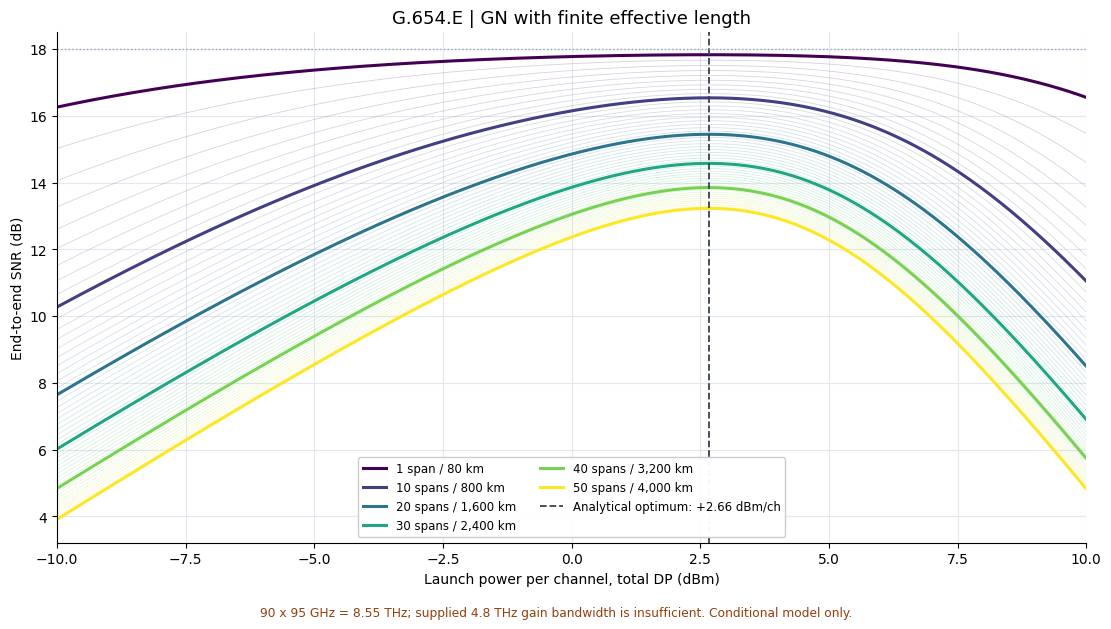

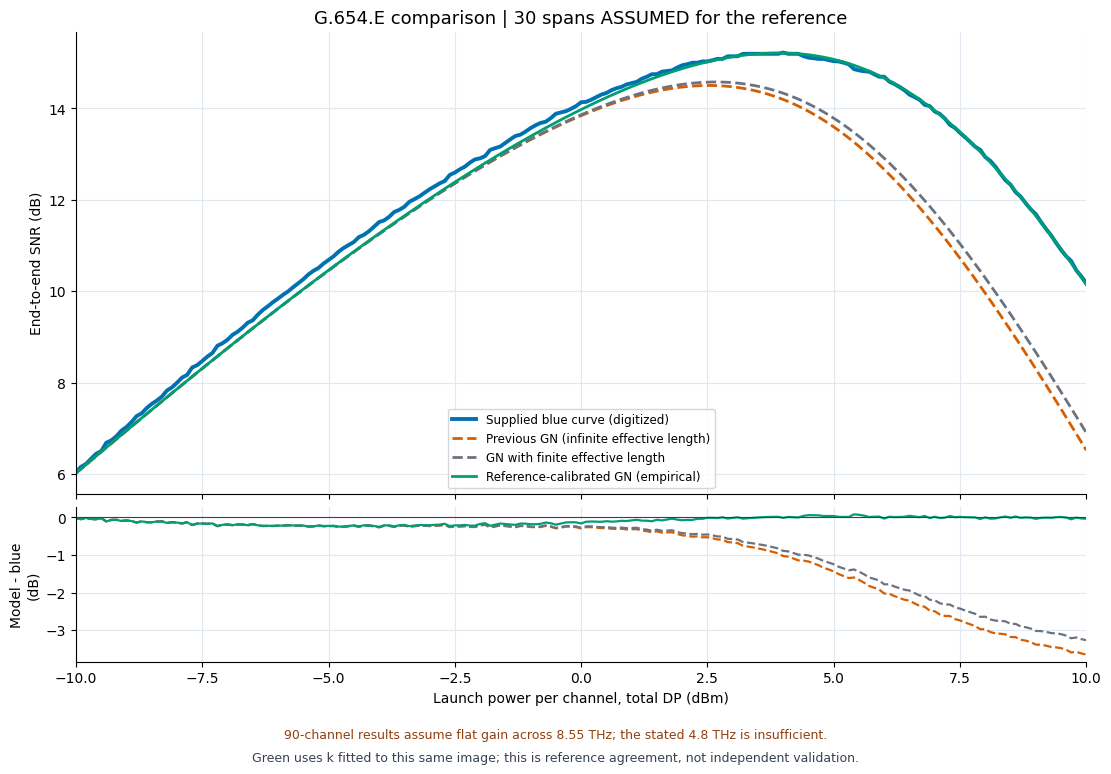

CSV/PNG/설정 ZIP: G654E_results/G654E_results.zip


/content/G654E_results/G654E_results.zip

In [1]:
"""G.654.E GN report: one main entry point; all launch powers are total DP power.
Source model: kimheeseo/LSCNS dnanf_fig2_hcf_colab.ipynb (retrieved 2026-09-08).
Change only USER_INPUTS. Fiber and source-system parameters are immutable.
"""

# ===================== 이 부분만 수정하세요 =====================
USER_INPUTS = {
    "task": "all",                   # all | snr | compare | point
    "model": "gn_finite",            # gn_finite | legacy | calibrated
    "spans": list(range(1, 51)),      # 계산할 span 수, 예: [10, 20, 30]
    "launch_min_dbm": -10.0,
    "launch_max_dbm": 10.0,
    "launch_step_db": 0.05,
    "point_launch_dbm": 4.0,          # 단일 운용점의 채널당 DP 전력
    "point_spans": 30,
    "reference_spans_assumed": 30,    # 첨부 그림에 없는 조건: 비교를 위한 가정
    "bandwidth_policy": "provisional", # provisional: 조건부 계산 | strict: 불일치 시 중지
    "include_historical_diagnostic": False, # 이전 4.8 THz ×0.5 진단선 추가
    "save_outputs": True,
    "show_outputs": True,
    "output_dir": "G654E_results",
}
# ================================================================

from dataclasses import dataclass, asdict
from pathlib import Path
import json
import platform
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import scipy

try:
    from IPython import get_ipython
    from IPython.display import display, Markdown, FileLink, HTML
    if get_ipython() is not None:
        get_ipython().run_line_magic("matplotlib", "inline")
except ImportError:
    display = Markdown = FileLink = None


@dataclass(frozen=True)
class FiberFixed:
    wavelength_nm: float = 1550.0
    attenuation_db_km: float = 0.166
    effective_area_um2: float = 125.0
    dispersion_ps_nm_km: float = 21.0
    n2_m2_w: float = 2.2e-20


@dataclass(frozen=True)
class SystemFixed:
    channels: int = 90
    symbol_rate_gbd: float = 95.0
    spacing_ghz: float = 95.0
    span_length_km: float = 80.0
    noise_figure_db: float = 5.0
    transceiver_snr_db: float = 18.0
    stated_gain_bandwidth_thz: float = 4.8
    qam_order_record_only: int = 64
    shannon_gap_db_record_only: float = 3.0
    polarizations: int = 2


FIBER = FiberFixed()
SYSTEM = SystemFixed()
C0 = 299_792_458.0
H_PLANCK = 6.626_070_15e-34
DB_PER_NEPER_POWER = 10.0 / np.log(10.0)
SOURCE_NOTEBOOK_URL = "https://github.com/kimheeseo/LSCNS/blob/main/paper/hcf-optimum-launch-power-reproduction/dnanf_fig2_hcf_colab.ipynb"
SOURCE_NOTEBOOK_SHA256 = "d99239f33a9082f6d38f29a9c16596a9284c4bb3ff7818518b3f909e5c21d8c8"
REFERENCE_IMAGE_SHA256 = "d23fa4e0c7c44246e25754f7be3315d8265243095a4ac7a94506bd0923e4d220"

# 첨부된 파란 곡선을 픽셀 좌표로 읽은 값. 실측 원시 데이터가 아닙니다.
# x: pixel 88 -> -10 dBm, 653 -> +10 dBm
# y: pixel 80 -> 16 dB, 331 -> 2 dB; 파란 선의 열별 중앙값을 선형 보간.
# 격자 0.1 dB는 이미지보다 촘촘하므로 201개 점은 독립 측정 201회가 아닙니다.
REFERENCE_X_DBM = np.linspace(-10.0, 10.0, 201)
REFERENCE_Y_DB = np.array([
    6.043824701195, 6.155378486056, 6.219521912351, 6.335956175299, 6.442629482072, 6.500498007968, 6.683864541833, 6.734760956175,
    6.824701195219, 6.948107569721, 7.026892430279, 7.135657370518, 7.265338645418, 7.326693227092, 7.441035856574, 7.532370517928,
    7.605577689243, 7.691334661355, 7.824501992032, 7.894223107570, 7.996015936255, 8.107569721116, 8.167529880478, 8.329282868526,
    8.380876494024, 8.470119521912, 8.566334661355, 8.645119521912, 8.804780876494, 8.858466135458, 8.937250996016, 9.043924302789,
    9.111553784861, 9.201494023904, 9.308167330677, 9.362549800797, 9.485258964143, 9.587051792829, 9.669322709163, 9.757868525896,
    9.836653386454, 9.920318725100, 9.994223107570, 10.086254980080, 10.171314741036, 10.258466135458, 10.363745019920, 10.443924302789,
    10.505976095618, 10.601494023904, 10.680278884462, 10.761155378486, 10.862948207171, 10.944521912351, 11.007968127490, 11.074203187251,
    11.180876494024, 11.231772908367, 11.310557768924, 11.408167330677, 11.509960159363, 11.546912350598, 11.625697211155, 11.731673306773,
    11.777689243028, 11.844621513944, 11.953386454183, 12.011952191235, 12.073306772908, 12.149302788845, 12.228087649402, 12.290836653386,
    12.357768924303, 12.408665338645, 12.541832669323, 12.594123505976, 12.664541832669, 12.723804780876, 12.812350597610, 12.881374501992,
    12.904382470120, 12.955278884462, 13.089840637450, 13.127490039841, 13.163745019920, 13.242529880478, 13.321314741036, 13.393824701195,
    13.423107569721, 13.490039840637, 13.566733067729, 13.629482071713, 13.679681274900, 13.705478087649, 13.784262948207, 13.880478087649,
    13.908366533865, 13.936952191235, 13.987848605578, 14.047808764940, 14.131474103586, 14.140537848606, 14.187250996016, 14.243027888446,
    14.298804780876, 14.333665338645, 14.395019920319, 14.438247011952, 14.468924302789, 14.521912350598, 14.549800796813, 14.577689243028,
    14.644621513944, 14.689243027888, 14.745019920319, 14.745019920319, 14.800796812749, 14.815438247012, 14.828685258964, 14.889342629482,
    14.940239043825, 14.963247011952, 14.996015936255, 14.996015936255, 15.023904382470, 15.023904382470, 15.050398406375, 15.079681274900,
    15.079681274900, 15.135458167331, 15.135458167331, 15.137549800797, 15.188446215139, 15.191235059761, 15.191235059761, 15.191235059761,
    15.191235059761, 15.191235059761, 15.191235059761, 15.191235059761, 15.219123505976, 15.191235059761, 15.191235059761, 15.191235059761,
    15.141035856574, 15.107569721116, 15.095019920319, 15.079681274900, 15.079681274900, 15.053884462151, 15.030876494024, 15.023904382470,
    14.996015936255, 14.961852589641, 14.856573705179, 14.828685258964, 14.809163346614, 14.800796812749, 14.745019920319, 14.689243027888,
    14.689243027888, 14.582569721116, 14.531673306773, 14.466135458167, 14.393625498008, 14.298804780876, 14.244422310757, 14.187250996016,
    14.075697211155, 14.047808764940, 13.929282868526, 13.876294820717, 13.774501992032, 13.637151394422, 13.570916334661, 13.462151394422,
    13.367330677291, 13.265537848606, 13.159561752988, 13.089840637450, 12.932270916335, 12.849302788845, 12.724501992032, 12.571115537849,
    12.424701195219, 12.329183266932, 12.166733067729, 12.067729083665, 11.922709163347, 11.790936254980, 11.684262948207, 11.517629482072,
    11.364940239044, 11.224800796813, 11.059561752988, 10.903386454183, 10.765338645418, 10.660059760956, 10.458565737052, 10.324003984064,
    10.171314741036,
], dtype=float)
REFERENCE_X_DBM.setflags(write=False)
REFERENCE_Y_DB.setflags(write=False)
_ALLOWED_INPUTS = frozenset({"task", "model", "spans", "launch_min_dbm", "launch_max_dbm",
    "launch_step_db", "point_launch_dbm", "point_spans", "reference_spans_assumed",
    "bandwidth_policy", "include_historical_diagnostic", "save_outputs", "show_outputs", "output_dir"})

MODEL_NAMES = {
    "legacy": "Previous GN (infinite effective length)",
    "gn_finite": "GN with finite effective length",
    "calibrated": "Reference-calibrated GN (empirical)",
    "historical_diagnostic": "Historical 4.8 THz x0.5 diagnostic",
}
MODEL_COLORS = {"legacy": "#D55E00", "gn_finite": "#6B7280",
                "calibrated": "#009E73", "historical_diagnostic": "#CC79A7"}


def _validate(user_inputs):
    allowed = _ALLOWED_INPUTS
    unknown = set(user_inputs) - allowed
    if unknown:
        raise ValueError(f"지원하지 않는 입력 또는 고정값 변경: {sorted(unknown)}")
    cfg = {**USER_INPUTS, **user_inputs}
    if asdict(FIBER) != asdict(FiberFixed()) or asdict(SYSTEM) != asdict(SystemFixed()):
        raise ValueError("고정 조건이 변경되었습니다. 원래 G.654.E/시스템 조건을 복구하세요.")
    if cfg["task"] not in {"all", "snr", "compare", "point"}:
        raise ValueError("task: all, snr, compare, point 중 하나를 입력하세요.")
    if cfg["model"] not in {"legacy", "gn_finite", "calibrated"}:
        raise ValueError("model: legacy, gn_finite, calibrated 중 하나를 입력하세요.")
    if cfg["bandwidth_policy"] not in {"provisional", "strict"}:
        raise ValueError("bandwidth_policy: provisional 또는 strict")
    vals = list(cfg["spans"])
    for name, value in [("spans", v) for v in vals] + [
        ("point_spans", cfg["point_spans"]),
        ("reference_spans_assumed", cfg["reference_spans_assumed"])]:
        if isinstance(value, bool) or not isinstance(value, (int, np.integer)) or not 1 <= value <= 50:
            raise ValueError(f"{name}: 원 조건 범위인 1~50의 정수만 입력하세요.")
    if not vals:
        raise ValueError("spans를 하나 이상 입력하세요.")
    cfg["spans"] = sorted(set(int(v) for v in vals))
    for key in ["launch_min_dbm", "launch_max_dbm", "launch_step_db", "point_launch_dbm"]:
        if isinstance(cfg[key], bool) or not np.isfinite(cfg[key]):
            raise ValueError(f"{key}: 유한한 숫자가 필요합니다.")
    lo, hi, step = [float(cfg[k]) for k in ["launch_min_dbm", "launch_max_dbm", "launch_step_db"]]
    if hi <= lo or step <= 0 or (hi-lo)/step > 20000:
        raise ValueError("전력 범위는 min < max, step > 0, 최대 20,001점으로 지정하세요.")
    if min(lo, cfg["point_launch_dbm"]) < -100 or max(hi, cfg["point_launch_dbm"]) > 40:
        raise ValueError("이 보고서의 수치 탐색 범위는 -100~+40 dBm/channel입니다.")
    return cfg


def derive_parameters():
    """Unit-safe conversion. Alpha here is POWER attenuation in km^-1."""
    lam = FIBER.wavelength_nm * 1e-9
    rate = SYSTEM.symbol_rate_gbd * 1e9
    alpha = FIBER.attenuation_db_km / DB_PER_NEPER_POWER
    beta2 = -(lam**2 / (2*np.pi*C0)) * (FIBER.dispersion_ps_nm_km*1e-6) * 1000
    gamma = 2*np.pi*FIBER.n2_m2_w / (lam*FIBER.effective_area_um2*1e-12) * 1000
    leff = -np.expm1(-alpha*SYSTEM.span_length_km) / alpha
    linf = 1/alpha
    gain = 10**(FIBER.attenuation_db_km*SYSTEM.span_length_km/10)
    ase = H_PLANCK*(C0/lam)*10**(SYSTEM.noise_figure_db/10)*rate*(gain-1)
    return {"wavelength_m": lam, "frequency_hz": C0/lam, "rate_hz": rate,
            "alpha_power_per_km": alpha, "alpha_field_per_km": alpha/2,
            "beta2_s2_per_km": beta2, "beta2_ps2_per_km": beta2*1e24,
            "gamma_per_w_km": gamma, "effective_length_km": leff,
            "asymptotic_length_km": linf,
            "span_gain_db": FIBER.attenuation_db_km*SYSTEM.span_length_km,
            "span_gain_linear": gain, "ase_per_span_w": ase,
            "wdm_occupied_bandwidth_thz": SYSTEM.channels*SYSTEM.spacing_ghz/1000,
            "channels_that_fit_4p8thz": int(SYSTEM.stated_gain_bandwidth_thz*1000//SYSTEM.spacing_ghz)}


def gn_eta_per_span(params, finite=True, bandwidth_thz=None):
    """Equal-channel central-channel GN approximation; eta excludes span count.
    Power P is total two-polarization channel power. No extra factor 0.5.
    Finite Leff improves the numerator; this remains a closed-form approximation.
    bandwidth_thz is used ONLY for the separately labelled historical diagnostic.
    """
    b, r = abs(params["beta2_s2_per_km"]), params["rate_hz"]
    linf = params["asymptotic_length_km"]
    leff = params["effective_length_km"] if finite else linf
    nch = SYSTEM.channels if bandwidth_thz is None else bandwidth_thz*1e12/(SYSTEM.spacing_ghz*1e9)
    argument = (np.pi**2/2)*b*linf*r**2*nch**(2*r/(SYSTEM.spacing_ghz*1e9))
    return float((8/27)*params["gamma_per_w_km"]**2*leff**2/(np.pi*b*linf*r**2)*np.arcsinh(argument))


def simulate(launch_dbm, spans, eta_per_span, params):
    launch = np.atleast_1d(np.asarray(launch_dbm, dtype=float))
    power = 1e-3*10**(launch/10)
    ase = np.full_like(power, spans*params["ase_per_span_w"])
    nli = spans*eta_per_span*power**3
    trx = power/10**(SYSTEM.transceiver_snr_db/10)
    snr = power/(ase+nli+trx)
    return pd.DataFrame({"launch_dbm": launch, "spans": spans,
        "distance_km": spans*SYSTEM.span_length_km, "signal_w": power,
        "ase_w": ase, "nli_w": nli, "trx_equivalent_noise_w": trx,
        "snr_linear": snr, "snr_db": 10*np.log10(snr)})


def optimum(eta, params):
    # d(ASE/P + eta*P^2 + 1/SNRtrx)/dP = 0; incoherent identical-span case.
    p = (params["ase_per_span_w"]/(2*eta))**(1/3)
    return float(10*np.log10(p/1e-3))


def fit_reference(params, eta_finite, assumed_spans):
    """Only one empirical k is fitted. Fiber, ASE, TRX and integer Ns stay fixed."""
    def residual(log_k):
        return simulate(REFERENCE_X_DBM, assumed_spans, eta_finite*np.exp(log_k[0]), params)["snr_db"].to_numpy()-REFERENCE_Y_DB
    fit = least_squares(residual, np.log([0.5]), bounds=(np.log([1e-4]), np.log([100.])),
                        ftol=1e-12, xtol=1e-12, gtol=1e-12)
    if not fit.success:
        raise RuntimeError("참조 곡선 보정계수 계산 실패: "+fit.message)
    return float(np.exp(fit.x[0]))


def error_metrics(predicted_db):
    delta = np.asarray(predicted_db)-REFERENCE_Y_DB
    # dB percentage is not meaningful: percentages are computed in linear SNR.
    return {"mae_db": float(np.mean(np.abs(delta))),
            "rmse_db": float(np.sqrt(np.mean(delta**2))),
            "max_abs_error_db": float(np.max(np.abs(delta))),
            "linear_snr_mape_pct": float(100*np.mean(np.abs(10**(delta/10)-1)))}


def _show_table(title, frame, enabled):
    if not enabled:
        return
    if display is not None:
        display(Markdown("**"+title+"**"))
        with pd.option_context("display.max_rows", 60, "display.max_columns", 20):
            display(HTML(frame.to_html(index=False, float_format=lambda v: f"{v:.7g}")))
    else:
        print(title)
        print(frame.to_string(index=False))


def _plot_snr(curves, cfg, params, eta):
    fig, ax = plt.subplots(figsize=(11, 6.5), layout="constrained")
    cmap = plt.get_cmap("viridis")
    selected = set(cfg["spans"]) if len(cfg["spans"]) <= 8 else {1,10,20,30,40,50,cfg["spans"][0],cfg["spans"][-1]}
    for ns, frame in curves.groupby("spans"):
        strong = ns in selected
        ax.plot(frame.launch_dbm, frame.snr_db, color=cmap((ns-1)/49),
                lw=2.2 if strong else 0.6, alpha=1 if strong else .20,
                label=f"{ns} {'span' if ns==1 else 'spans'} / {ns*80:,} km" if strong else None)
    p_opt = optimum(eta, params)
    if cfg["launch_min_dbm"] <= p_opt <= cfg["launch_max_dbm"]:
        ax.axvline(p_opt, color="#374151", ls="--", lw=1.3, label=f"Analytical optimum: {p_opt:+.2f} dBm/ch")
    ax.axhline(18, color="#94A3B8", ls=":", lw=1)
    ax.set(xlabel="Launch power per channel, total DP (dBm)", ylabel="End-to-end SNR (dB)",
           title="G.654.E | "+MODEL_NAMES[cfg["model"]],
           xlim=(cfg["launch_min_dbm"],cfg["launch_max_dbm"]))
    ax.grid(color="#E2E8F0", lw=.8)
    ax.spines[["top","right"]].set_visible(False)
    ax.legend(loc="lower center", ncol=2, fontsize=8.5, framealpha=.97)
    fig.get_layout_engine().set(rect=(0,.065,1,.90))
    fig.text(.5,.025,"90 x 95 GHz = 8.55 THz; supplied 4.8 THz gain bandwidth is insufficient. Conditional model only.",
             ha="center", fontsize=8.8, color="#92400E")
    return fig


def _plot_comparison(comparison, cfg):
    fig, (ax, err) = plt.subplots(2,1,figsize=(11,8),sharex=True,
                                 gridspec_kw={"height_ratios":[3,1]},layout="constrained")
    x = comparison.launch_dbm
    ax.plot(x, comparison.reference_snr_db, color="#0072B2", lw=2.8, label="Supplied blue curve (digitized)")
    models = ["legacy","gn_finite","calibrated"]
    if cfg["include_historical_diagnostic"]:
        models.append("historical_diagnostic")
    for model in models:
        y = comparison[model+"_snr_db"]
        style = "-" if model=="calibrated" else "--"
        ax.plot(x,y,lw=2,ls=style,color=MODEL_COLORS[model],label=MODEL_NAMES[model])
        err.plot(x,y-comparison.reference_snr_db,lw=1.6,ls=style,color=MODEL_COLORS[model])
    ax.set(title=f"G.654.E comparison | {cfg['reference_spans_assumed']} spans ASSUMED for the reference",
           ylabel="End-to-end SNR (dB)")
    ax.legend(loc="lower center",fontsize=8.6)
    err.axhline(0,color="#374151",lw=.8)
    err.set(xlabel="Launch power per channel, total DP (dBm)",ylabel="Model - blue\n(dB)",xlim=(-10,10))
    for a in [ax,err]:
        a.grid(color="#E2E8F0",lw=.8)
        a.spines[["top","right"]].set_visible(False)
    fig.get_layout_engine().set(rect=(0,.085,1,.88))
    fig.text(.5,.048,"90-channel results assume flat gain across 8.55 THz; the stated 4.8 THz is insufficient.",
             ha="center",fontsize=9,color="#92400E")
    fig.text(.5,.020,"Green uses k fitted to this same image; this is reference agreement, not independent validation.",
             ha="center",fontsize=9,color="#374151")
    return fig


def main(user_inputs=None):
    """Return tables, metadata and figures; change USER_INPUTS to select results."""
    cfg = _validate({} if user_inputs is None else user_inputs)
    p = derive_parameters()
    conflict = p["wdm_occupied_bandwidth_thz"] > SYSTEM.stated_gain_bandwidth_thz
    message = ("입력 정합성: 90채널 × 95 GHz = 8.55 THz이며, 제시된 증폭 대역폭 4.8 THz를 초과합니다. "
               "원 입력은 변경하지 않았습니다. 계산에는 90채널을 사용하며, 전 대역 평탄 이득을 가정한 조건부 결과입니다.")
    if conflict and cfg["bandwidth_policy"] == "strict":
        raise ValueError(message+" strict 정책으로 계산을 중지합니다.")
    if cfg["show_outputs"]:
        print(message)
        print("비교 그림의 span 수는 미표기: reference_spans_assumed는 비교용 가정입니다.")
        if cfg["model"] == "calibrated":
            print("calibrated 선택: 동일 그림에서 추정한 k를 사용합니다. 다른 span에의 전이는 미검증입니다.")
    eta_legacy = gn_eta_per_span(p, finite=False)
    eta_finite = gn_eta_per_span(p, finite=True)
    k = fit_reference(p, eta_finite, cfg["reference_spans_assumed"])
    # 이전 답변의 숫자를 재현하기 위해서만 4.343 반올림을 보존합니다.
    historical_params = dict(p)
    historical_a = FIBER.attenuation_db_km/4.343
    historical_params.update(effective_length_km=-np.expm1(-historical_a*80)/historical_a,
                             asymptotic_length_km=1/historical_a)
    eta_4p8_inf = gn_eta_per_span(p, finite=False, bandwidth_thz=4.8)
    eta_4p8_fin = gn_eta_per_span(historical_params, finite=True, bandwidth_thz=4.8)
    etas = {"legacy": eta_legacy, "gn_finite": eta_finite, "calibrated": k*eta_finite,
            "historical_diagnostic": .5*eta_4p8_fin}
    selected_eta = etas[cfg["model"]]
    grid = np.arange(cfg["launch_min_dbm"],cfg["launch_max_dbm"]+cfg["launch_step_db"]*1e-7,cfg["launch_step_db"])
    if grid[-1] < cfg["launch_max_dbm"]-1e-8:
        grid = np.append(grid,cfg["launch_max_dbm"])
    curves = pd.concat([simulate(grid,ns,selected_eta,p) for ns in cfg["spans"]],ignore_index=True)
    curves["model"] = cfg["model"]
    curves["conditional_bandwidth_conflict"] = conflict
    p_opt = optimum(selected_eta,p)
    opt_rows = []
    for ns, frame in curves.groupby("spans"):
        opt = simulate([p_opt],int(ns),selected_eta,p).iloc[0]
        sample = frame.loc[frame.snr_db.idxmax()]
        opt_rows.append({"spans": int(ns), "distance_km": int(ns)*80,
            "analytic_optimum_launch_dbm": p_opt, "analytic_max_snr_db": opt.snr_db,
            "grid_best_launch_dbm": sample.launch_dbm, "grid_best_snr_db": sample.snr_db,
            "optimum_inside_scan": bool(grid[0]<=p_opt<=grid[-1]), "model": cfg["model"]})
    optimum_table = pd.DataFrame(opt_rows)
    point = simulate([cfg["point_launch_dbm"]],cfg["point_spans"],selected_eta,p)
    point["model"] = cfg["model"]
    comparison = pd.DataFrame({"launch_dbm":REFERENCE_X_DBM,"reference_snr_db":REFERENCE_Y_DB})
    metric_rows = []
    for model, eta in etas.items():
        pred = simulate(REFERENCE_X_DBM,cfg["reference_spans_assumed"],eta,p).snr_db.to_numpy()
        comparison[model+"_snr_db"] = pred
        comparison[model+"_error_db"] = pred-REFERENCE_Y_DB
        best_p = optimum(eta,p)
        metric_rows.append({"model":model,"spans_assumed":cfg["reference_spans_assumed"],
            "eta_per_span_w_inv2":eta, "optimum_launch_dbm":best_p,
            "maximum_snr_db":float(simulate([best_p],cfg["reference_spans_assumed"],eta,p).snr_db.iloc[0]),
            **error_metrics(pred)})
    metrics = pd.DataFrame(metric_rows)
    stages = pd.DataFrame([
        ["Previous infinite-length, 90ch",eta_legacy,"provisional 8.55 THz"],
        ["Finite effective length, 90ch",eta_finite,"main GN baseline; k=1"],
        ["Calibrated finite GN, 90ch",k*eta_finite,f"empirical k={k:.8f}; Ns assumed"],
        ["Historical: infinite-length, 4.8 THz",eta_4p8_inf,"incompatible with 90 Nyquist channels"],
        ["Historical: finite length, 4.8 THz",eta_4p8_fin,"diagnostic only"],
        ["Historical: finite, 4.8 THz, x0.5",.5*eta_4p8_fin,"0.5 has no verified polarization justification"],
    ],columns=["stage","eta_per_span_w_inv2","meaning"])
    metadata = {"report_version":"2026-09-08.1", "fiber_fixed":asdict(FIBER),"system_fixed":asdict(SYSTEM),
        "user_inputs":cfg,"derived":p,"eta_models_per_span_w_inv2":etas,"empirical_k":k,
        "bandwidth_conflict":conflict,"reference_spans_known":False,
        "reference_kind":"user-supplied raster graph; experimental status unknown",
        "reference_pixel_scale_db":14/251,"reference_uncertainty_note":"about +/-0.1 dB; heuristic, not a confidence interval",
        "reference_peak_launch_dbm":float(REFERENCE_X_DBM[np.argmax(REFERENCE_Y_DB)]),
        "reference_peak_snr_db":float(np.max(REFERENCE_Y_DB)),
        "source_notebook_url":SOURCE_NOTEBOOK_URL,"source_notebook_sha256":SOURCE_NOTEBOOK_SHA256,
        "reference_image_sha256":REFERENCE_IMAGE_SHA256,
        "versions":{"python":platform.python_version(),"numpy":np.__version__,"pandas":pd.__version__,"scipy":scipy.__version__},
        "assumptions":["identical 80 km spans; one loss-compensating amplifier per span",
                       "constant NF; no saturation; incoherent NLI accumulation; central-channel approximation",
                       "signal power is total DP power; no additional polarization factor",
                       "no inter-channel Raman scattering, gain tilt, PMD/PDL or filter penalties",
                       "64QAM and Shannon gap are recorded but not used in physical SNR",
                       "span count is not a wet-repeater count; receiver-end amplifier is included"]}
    tables = {"derived_parameters":pd.DataFrame(p.items(),columns=["parameter","value"]),
        "fiber_fixed":pd.DataFrame(asdict(FIBER).items(),columns=["parameter","value"]),
        "system_fixed":pd.DataFrame(asdict(SYSTEM).items(),columns=["parameter","value"]),
        "snr_curves":curves,"optimum_summary":optimum_table,"operating_point":point,
        "reference_comparison":comparison,"reference_error_metrics":metrics,"eta_stages":stages}
    figures = {}
    plt.rcParams.update({"font.family":"DejaVu Sans","font.size":10,"axes.titlesize":13,"savefig.facecolor":"white"})
    if cfg["task"] in {"all","snr"}:
        figures["G654E_snr_vs_launch"] = _plot_snr(curves,cfg,p,selected_eta)
    if cfg["task"] in {"all","compare"}:
        figures["G654E_reference_comparison"] = _plot_comparison(comparison,cfg)
    _show_table("고정 G.654.E 물성",tables["fiber_fixed"],cfg["show_outputs"])
    _show_table("계산된 주요 파라미터",tables["derived_parameters"],cfg["show_outputs"])
    if cfg["task"] in {"all","snr"}:
        excerpt = optimum_table if len(optimum_table)<=10 else optimum_table[optimum_table.spans.isin([1,10,20,30,40,50])]
        _show_table("최적점 요약 (전체 span 결과는 CSV)",excerpt,cfg["show_outputs"])
    if cfg["task"] in {"all","compare"}:
        _show_table("첨부 파란 곡선과의 일치도: 동일 그림 보정 포함",metrics,cfg["show_outputs"])
        _show_table("η 변화 단계: 과거 진단 조건까지 공개",stages,cfg["show_outputs"])
    if cfg["task"] in {"all","point"}:
        _show_table("입력 운용점의 SNR 및 잡음 성분",point,cfg["show_outputs"])
    out = Path(cfg["output_dir"])
    saved = []
    if cfg["save_outputs"]:
        out.mkdir(parents=True,exist_ok=True)
        for name,frame in tables.items():
            path=out/(name+".csv")
            frame.to_csv(path,index=False,encoding="utf-8-sig")
            saved.append(path)
        meta_path=out/"parameters_and_provenance.json"
        meta_path.write_text(json.dumps(metadata,ensure_ascii=False,indent=2),encoding="utf-8")
        saved.append(meta_path)
        for name,fig in figures.items():
            path=out/(name+".png")
            fig.savefig(path,dpi=180)
            saved.append(path)
        zip_path=out/"G654E_results.zip"
        with zipfile.ZipFile(zip_path,"w",zipfile.ZIP_DEFLATED) as z:
            for path in saved:
                z.write(path,path.name)
    if cfg["show_outputs"]:
        plt.show()
        if cfg["save_outputs"]:
            print("CSV/PNG/설정 ZIP:", str(out/"G654E_results.zip"))
            if display is not None:
                display(FileLink(str(out/"G654E_results.zip")))
    else:
        for fig in figures.values():
            plt.close(fig)
    return {"config":cfg,"parameters":p,"eta":etas,"empirical_k":k,
            "tables":tables,"figures":figures,"metadata":metadata}


if __name__ == "__main__":
    RESULTS = main(USER_INPUTS)


## 7. 결과 해석 범위

기본 GN과 파란 곡선에 차이가 남더라도 네 G.654.E 물성을 임의로 바꾸어 맞추지 않았습니다. `calibrated`의 작은 잔차는 **동일 그림에 대한 맞춤 정도**입니다. 원 그래프가 실험 결과인지, 어떤 span 수·채널 대역폭·수신 성능 정의를 사용했는지 확인하지 않은 상태에서 이를 광섬유 예측 오차로 단정할 수 없습니다.

이전 두 변수 역산에서는 유효 span 수가 약 28.67, span당 η가 약 27.74로 나왔지만 이는 두 변수를 동시에 피팅한 값입니다. 본 실행본은 `reference_spans_assumed=30`을 유지하고 η 배율 k만 조정하므로 보정 η가 이 값과 달라지는 것이 자연스럽습니다. **피팅한 유효 span 수를 실제 리피터 개수로 사용하지 않습니다.**

GN 수식의 단위·수치 일치, 최적점 수식, 고정값 보존, 노트북 실행은 검증할 수 있습니다. 별도의 실험·SSFM·EGN 데이터로 성능을 입증하려면 그 조건과 자료가 추가로 필요합니다. 특히 8.55 THz 전 대역 예측은 이 보고서가 생략한 ISRS와 파장별 이득/물성까지 검토해야 합니다.[2,3]

## 8. 원본 자료 및 출처

1. [사용자 지정 원본 GitHub 노트북](https://github.com/kimheeseo/LSCNS/blob/main/paper/hcf-optimum-launch-power-reproduction/dnanf_fig2_hcf_colab.ipynb). 2026-09-08 원본 바이트를 확보해 `closed_form_gn_eta`, `per_channel_ase_w`, SNR 합산부를 대조했습니다. SHA-256: `d99239f33a9082f6d38f29a9c16596a9284c4bb3ff7818518b3f909e5c21d8c8`.
2. P. Poggiolini et al., [A Detailed Analytical Derivation of the GN Model of Non-Linear Interference in Coherent Optical Transmission Systems](https://arxiv.org/abs/1209.0394), v13 (2014). [PDF](https://arxiv.org/pdf/1209.0394), pp.18–19, Eqs.(120), (123)–(124): 유효길이, SCI/XCI, 비상관 span 누적을 확인했습니다. 본 보고서의 폐형 식과 SCI/XCI 합의 수치 일치는 수식 정합성 점검이며 실측 검증이 아닙니다.
3. [GNPy 공식 물리 모델 설명](https://gnpy.readthedocs.io/en/master/model.html): GN 모델의 가정과 넓은 대역에서 Raman 상호작용을 고려해야 하는 적용 범위.
4. [The GN Model of Non-Linear Propagation in Uncompensated Coherent Optical Systems](https://opg.optica.org/jlt/abstract.cfm?URI=jlt-30-24-3857), JLT 30(24), 3857–3879 (2012), DOI: 10.1109/JLT.2012.2217729.
5. 사용자 첨부 자료: G.654.E/ G.652 물성 비교표, Simulation Parameters 그림, G.654.E 파란 SNR 그래프. 출판 원본과 실험 여부는 확인되지 않았습니다. 물성 수치와 비교 곡선의 직접 근거는 이 첨부 자료입니다.
6. 같은 대화의 기존 실행 파일 `g654e_launch_power_snr.py`, `compare_g654e_reference_vs_previous.py`: 이전 계산과 과거 진단 결과 재현에 사용했습니다.

아래 원본 이미지는 자료 확인용입니다. 코드 실행에는 외부 이미지 파일이 필요하지 않습니다.

**사용자 첨부 물성표**

![G654E inputs](attachment:fiber_inputs.png)

**사용자 첨부 시스템 조건**

![System inputs](attachment:system_inputs.png)

**사용자 첨부 기준 그래프**

![Blue reference](attachment:reference_blue.png)

## 9. 배포본 실행 검증 기록 — 기본 입력 기준

이 절은 배포 시점의 검증 기록입니다. USER_INPUTS를 바꾼 뒤에는 코드 셀의 출력표를 현재 결과로 사용하세요.

| 검증 항목 | 확인 결과 |
|---|---|
| 코드 셀 / 실행 오류 | 1개 / 0개 |
| 저장된 그래프 | 2개, 제목·축·범례·곡선 육안 확인 |
| 고정 물성 유지 | α=0.166, Aeff=125, D=21, n₂=2.2×10⁻²⁰ 유지 |
| 기존 GitHub GN·ASE 함수와 수치 대조 | 통과; 기존 η=68.237665 W⁻²/span 재현 |
| 유한 Leff GN과 논문 SCI/XCI 합 비교 | 61.975439 vs 61.973646 W⁻²/span, 차이 0.00289% |
| 해석식 최적전력 / 0.005 dB 격자 탐색 | +2.664389 / +2.665 dBm |
| 입력값 변경 | 다른 span·launch power에서 출력 변경 확인 |
| 잘못된 입력·고정값 변경·strict 대역폭 검사 | 의도한 오류 발생 확인 |

**SCI/XCI 합과의 0.00289% 차이는 계산식 사이의 일치도이며 실험 대비 오차율이 아닙니다.**

기본 비교 가정은 30 spans입니다. 아래 값은 동일 파란 그림에 대한 비교 결과입니다.

| 모델 | η [W⁻²/span] | 최적 launch [dBm] | 최대 SNR [dB] | 파란 곡선 RMSE [dB] |
|---|---:|---:|---:|---:|
| 이전 GN | 68.238 | +2.525 | 14.498 | 1.442 |
| 유한 Leff 기본 GN | 61.975 | +2.664 | 14.575 | 1.279 |
| 경험적 보정 GN | 26.216 | +3.910 | 15.210 | 0.133 |
| 과거 4.8 THz·×0.5 진단 | 28.264 | +3.801 | 15.158 | 0.165 |

첨부 파란 곡선의 판독 peak는 약 +4.0 dBm / 15.22 dB입니다. 경험적 보정은 k≈0.4230을 사용하며, 30 spans 가정 아래 동일 그림에 맞춘 결과입니다. 그 RMSE를 다른 링크·실측 시스템의 예측 정확도로 확장해서 해석하지 않습니다.
